INDIA GROWTH RATE PREDICTION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

data = pd.DataFrame({
    "Year": [1951, 1961, 1971, 1981, 1991, 2001, 2011],
    "Population":[361088000,439235000,548160000,683329000,846421000,1028737436,1210854977]
})

Feature Engineering

In [ ]:
data['GrowthRate'] = data['Population'].pct_change() * 100
data =  data.dropna()
print("Dataset:\n", data)

Dataset:
    Year  Population  GrowthRate
1  1961   439235000   21.642093
2  1971   548160000   24.798798
3  1981   683329000   24.658676
4  1991   846421000   23.867273
5  2001  1028737436   21.539687
6  2011  1210854977   17.703015


Define Feature

In [ ]:
x = data[['Year']]
y = data[['GrowthRate']]

Linear Regression

In [ ]:
lin_model = LinearRegression()
lin_model.fit(x, y)

lin_pred = lin_model.predict(x)

Polnomial Regression

In [ ]:
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

poly_model = LinearRegression()
poly_model.fit(x_poly, y)
poly_pred = poly_model.predict(x_poly)


Random forest

In [ ]:
rf_model=  RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x, y)
rf_pred = rf_model.predict(x)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model Accuracy

In [ ]:
print("\nModel Accuracy(R2 Score):")
print("Linear:", r2_score(y, lin_pred))
print("Polynomial:", r2_score(y, poly_pred))
print("Random Forest:" ,r2_score(y, rf_pred))


Model Accuracy(R2 Score):
Linear: 0.3596734002219246
Polynomial: 0.9850857918774119
Random Forest: 0.8987344786432047


Future Prediction

In [ ]:
future_years = pd.DataFrame({'Year': [2025, 2030, 2040, 2050]})

lin_future = lin_model.predict(future_years)
poly_future = poly_model.predict(poly.transform(future_years))
rf_future = rf_model.predict(future_years)

print("\nFuture Growth Rate Predictions:")
for i, year in enumerate(future_years['Year']):
  print(f"{year} -> Linear: {lin_future[i].item():.2f}% | Polynomial: {poly_future[i].item():.2f}% | RF: {rf_future[i].item():.2f}%")


Future Growth Rate Predictions:
2025 -> Linear: 19.00% | Polynomial: 9.40% | RF: 19.12%
2030 -> Linear: 18.56% | Polynomial: 5.73% | RF: 19.12%
2040 -> Linear: 17.70% | Polynomial: -2.79% | RF: 19.12%
2050 -> Linear: 16.83% | Polynomial: -12.86% | RF: 19.12%


Visualization

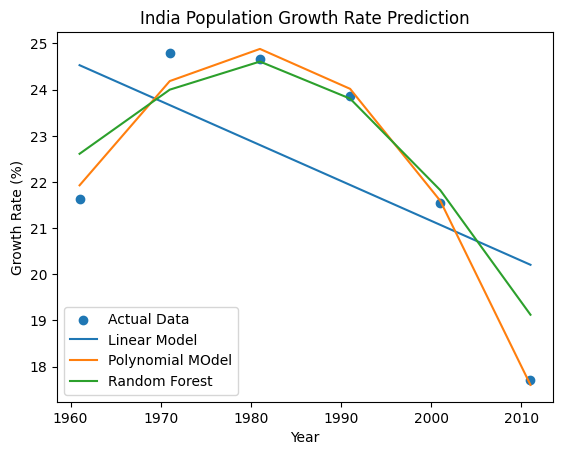

In [ ]:
plt.figure

plt.scatter(x, y, label='Actual Data')
plt.plot(x, lin_pred, label='Linear Model')
plt.plot(x, poly_pred, label='Polynomial MOdel')
plt.plot(x, rf_pred, label='Random Forest')


plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.title("India Population Growth Rate Prediction")
plt.legend()

plt.show()